In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense





df = pd.read_csv("C:\\Users\\PC\\Desktop\\AiProject\\WSP.csv")


#Perforing EDA
df[['Open', 'High', 'Low']].isnull().sum()

df[['Open', 'High', 'Low']] = df[['Open', 'High', 'Low']].fillna(df[['Open', 'High', 'Low']].median())



In [4]:
df = df[df['Brand_Name'] == 'puma'].copy()  # Filter only AMD if needed

df['Date'] = pd.to_datetime(df['Date'], utc=True)

# Step 2: Define timezone-aware date range
start_date = pd.Timestamp('2024-01-01', tz='UTC')
end_date = pd.Timestamp('2025-12-31', tz='UTC')

# Step 3: Filter between the range
df = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)]

# Check result
print(df)

                           Date       Open       High        Low      Close  \
4     2025-05-05 04:00:00+00:00  27.278000  27.278000  27.278000  27.278000   
84    2025-05-02 04:00:00+00:00  25.143000  25.143000  25.143000  25.143000   
178   2025-05-02 04:00:00+00:00  21.600000  21.600000  21.600000  25.143000   
180   2025-05-01 04:00:00+00:00  25.143000  25.143000  25.143000  25.143000   
276   2025-04-30 04:00:00+00:00  26.350000  26.350000  25.143000  25.143000   
...                         ...        ...        ...        ...        ...   
23132 2024-01-08 05:00:00+00:00  50.395218  50.395218  50.395218  50.395218   
23202 2024-01-05 05:00:00+00:00  51.231529  51.231529  51.231529  51.231529   
23250 2024-01-04 05:00:00+00:00  49.598262  51.162659  49.598262  51.162659   
23297 2024-01-03 05:00:00+00:00  53.888054  53.888054  53.888054  53.888054   
23361 2024-01-02 05:00:00+00:00  54.114349  54.452812  54.114349  54.345566   

       Volume  Dividends  Stock Splits Brand_Name T

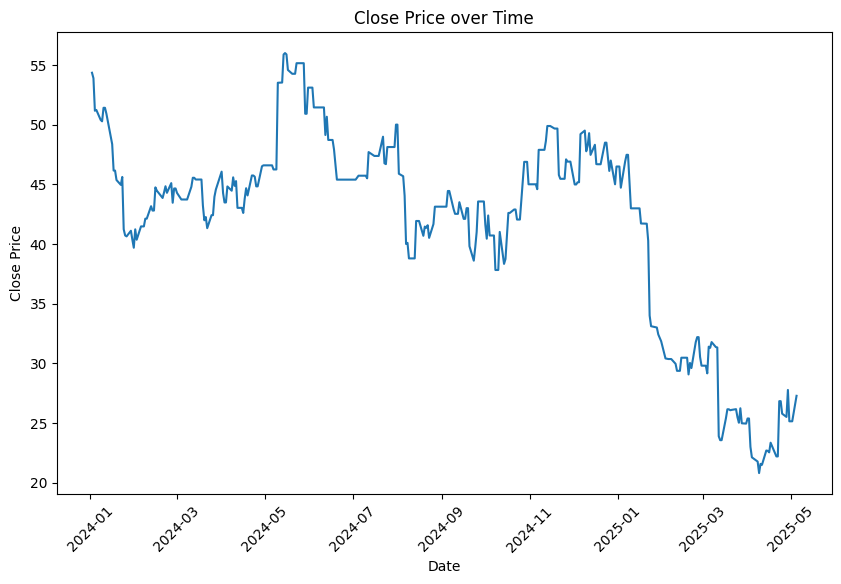

In [5]:


# Line plot: 'Close' values over 'Date'
plt.figure(figsize=(10, 6))
plt.plot(df['Date'], df['Close'])
plt.title("Close Price over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.xticks(rotation=45)
plt.show()

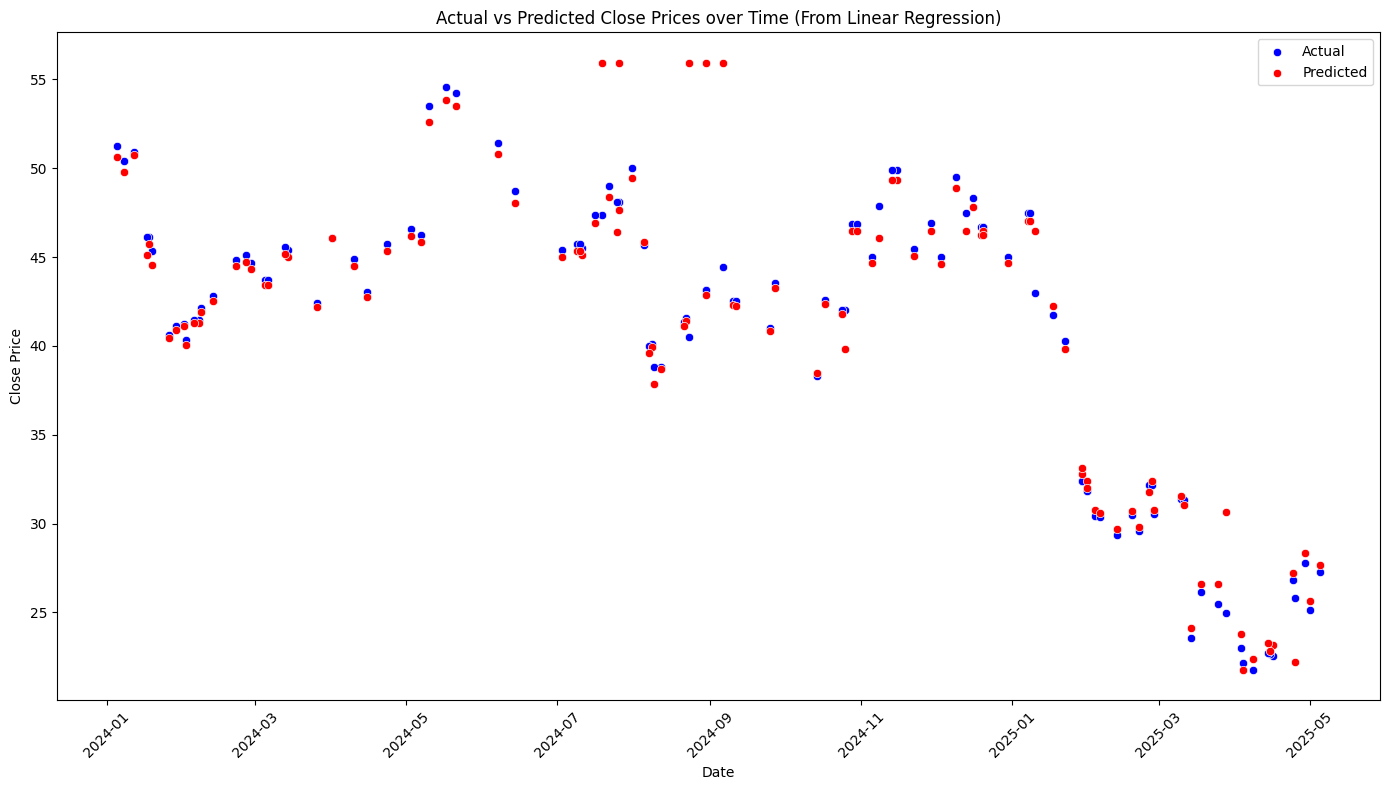

In [6]:
# Step 1: Split data (keep original indices intact)
def rae(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true - np.mean(y_true)))




Feature = ['Open','High','Low']
X = df[Feature]
y = df['Close']

#scaling 
scale = StandardScaler()
X_scaled = scale.fit_transform(X)
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

# ✅ Get dates from original df using y_test's index
dates_test = df.loc[y_test.index, 'Date']

# Reset indices
y_test = y_test.reset_index(drop=True)
X_test = pd.DataFrame(X_test).reset_index(drop=True)
dates_test = dates_test.reset_index(drop=True)

model = LinearRegression()
model.fit(X_train, y_train)
# Step 4: Predict
Lr_pred = model.predict(X_test)

Lr_Score = r2_score(y_test,Lr_pred)
Lr_Mse = mean_squared_error(y_test,Lr_pred)
Lr_Mae = rae(y_test,Lr_pred)

plt.figure(figsize=(14, 8))
sns.scatterplot(x=dates_test, y=y_test, label='Actual',color = 'blue')
sns.scatterplot(x=dates_test, y=Lr_pred, label='Predicted',color = 'red')
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("Actual vs Predicted Close Prices over Time (From Linear Regression)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


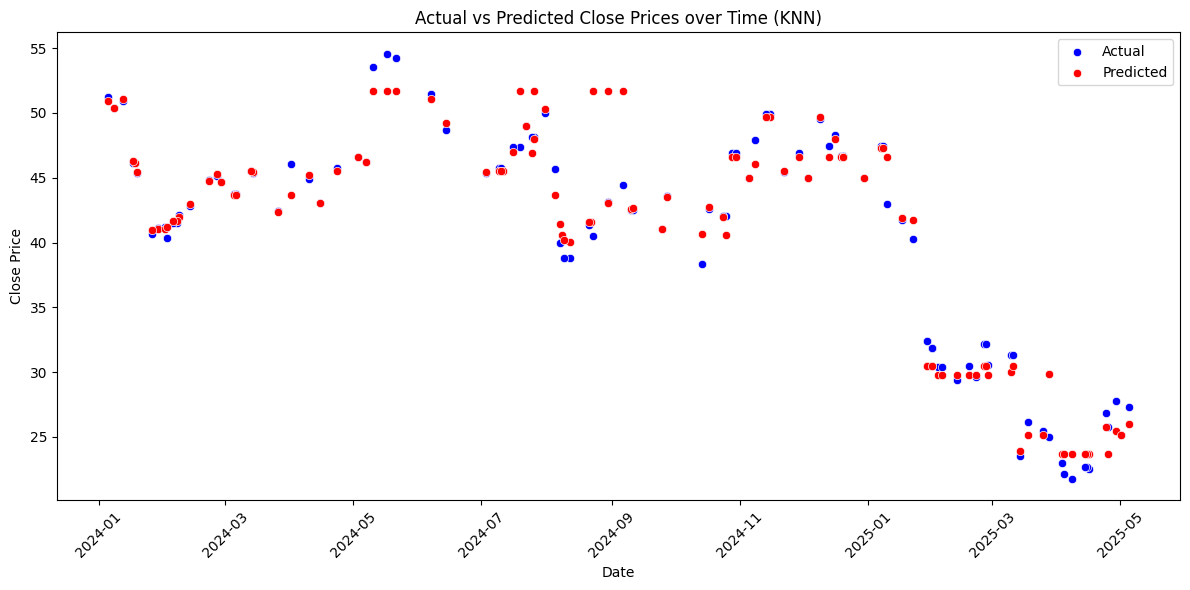

In [7]:


# Save original Date column
from sklearn.neighbors import KNeighborsRegressor


# Scaling
scale = StandardScaler()
X_scaled = scale.fit_transform(X)

# Keep indices intact for later date mapping
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_scaled, y, df.index, test_size=0.3, random_state=42
)

# KNN Model
knn = KNeighborsRegressor(n_neighbors=20)
knn.fit(X_train, y_train)
Knn_pred = knn.predict(X_test)

Knn_Score = r2_score(y_test,Knn_pred)
Knn_Mse = mean_squared_error(y_test,Knn_pred)
Knn_Mae = rae(y_test,Knn_pred)



# Get matching dates for X_test
dates_test = df.loc[idx_test, 'Date'].reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

# Plotting
plt.figure(figsize=(12, 6))
sns.scatterplot(x=dates_test, y=y_test, label='Actual', color='blue')
sns.scatterplot(x=dates_test, y=Knn_pred, label='Predicted', color='red')
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("Actual vs Predicted Close Prices over Time (KNN)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:



scaler_X = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)

scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))


# Function to create sequences (10-day windows)
def create_sequences(X, y, window_size=10):
    Xs, ys = [], []
    for i in range(len(X) - window_size):
        Xs.append(X[i:i+window_size])
        ys.append(y[i+window_size])
    return np.array(Xs), np.array(ys)

# Create sequences
X_seq, y_seq = create_sequences(X_scaled, y_scaled)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.3, random_state=42)

# LSTM model
model = Sequential()
model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))
model.add(LSTM(64))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mae')

# Train
model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=1)

# Predict & inverse scale


Epoch 1/50


In [ ]:
y_pred_LSTM = model.predict(X_test)


# Flatten the actual and predicted values
y_actual_flat = y_test.ravel()
y_pred_flat = y_pred_LSTM.ravel()

LSTM_Score = r2_score(y_actual_flat,y_pred_flat)
LSTM_Mse = mean_squared_error(y_actual_flat,y_pred_flat)
LSTM_Mae = rae(y_actual_flat,y_pred_flat)


# Plot
plt.figure(figsize=(14, 8))
plt.plot(y_actual_flat, label='Actual', color='blue')
plt.plot(y_pred_flat, label='Predicted', color='red')
plt.title("LSTM: Actual vs Predicted Close Prices (USING LSTM)")
plt.xlabel("Sample Index")
plt.ylabel("Close Price")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
Scores = {
    "kNN": Knn_Score,
    "LSTM": LSTM_Score,
    "Linear Regression": Lr_Score
}

Board = pd.DataFrame({'Model':['Linear Regression','Knn','LSTM'],
                      'MSE':[Lr_Mse,Knn_Mse,LSTM_Mse],
                      'MAE':[Lr_Mae,Knn_Mae,LSTM_Mae],
                      'ACCURACY':[Lr_Score,Knn_Score,LSTM_Score]}
                      )

print(Board)
best_model_name = max(Scores, key=Scores.get)
best_Score = Scores[best_model_name]

print(f"\n✅ Best Model: {best_model_name} with Accuracy: {best_Score:.3f}")



               Model       MSE       MAE  ACCURACY
0  Linear Regression  6.717657  0.150666  0.905608
1                Knn  3.693476  0.141768  0.948102
2               LSTM  0.003776  0.446619  0.830601

✅ Best Model: kNN with Accuracy: 0.948
